<a href="https://colab.research.google.com/github/alaaguedda/CNN_object_recognition/blob/main/CNN_trained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# Lab 05 - CNN Image Classification (Fashion-MNIST)
# ==========================================================
# Install libraries if running on a fresh environment
# (Colab usually already has them)
# ==========================================================

!pip install tensorflow numpy matplotlib -q

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [ ]:
# ==========================================================
# Reproducibility
# Setting seeds ensures the same results every run
# ==========================================================

def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)


# ==========================================================
# Load Fashion-MNIST Dataset
# 60,000 training images
# 10,000 test images
# Image size: 28x28 grayscale
# ==========================================================

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
"T-shirt/top","Trouser","Pullover","Dress","Coat",
"Sandal","Shirt","Sneaker","Bag","Ankle boot"
]


# ==========================================================
# Data preprocessing
# 1. Normalize pixel values (0 → 255) to (0 → 1)
# 2. Add channel dimension -> (28,28,1)
# CNN expects (Height, Width, Channels)
# ==========================================================

x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test  = (x_test.astype("float32") / 255.0)[..., None]

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)


Train shape: (60000, 28, 28, 1) (60000,)
Test shape: (10000, 28, 28, 1) (10000,)


In [ ]:
# ==========================================================
# CNN Builder Function
# This function allows us to easily modify:
# - number of filters
# - kernel size
# - dropout
# - batch normalization
# ==========================================================

def build_cnn(input_shape=(28,28,1),
              filters=(32,64),
              kernel_size=3,
              dropout=False,
              batchnorm=False,
              lr=1e-3):

    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))

    # -----------------------------
    # Convolution Block 1
    # -----------------------------
    model.add(layers.Conv2D(filters[0],
                            kernel_size,
                            padding="same",
                            activation="relu"))

    if batchnorm:
        model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D((2,2)))

    if dropout:
        model.add(layers.Dropout(0.25))


    # -----------------------------
    # Convolution Block 2
    # -----------------------------
    model.add(layers.Conv2D(filters[1],
                            kernel_size,
                            padding="same",
                            activation="relu"))

    if batchnorm:
        model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D((2,2)))

    if dropout:
        model.add(layers.Dropout(0.25))


    # -----------------------------
    # Classifier
    # -----------------------------
    model.add(layers.Flatten())

    model.add(layers.Dense(128, activation="relu"))

    if dropout:
        model.add(layers.Dropout(0.5))

    model.add(layers.Dense(10, activation="softmax"))


    # -----------------------------
    # Compile model
    # -----------------------------
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model


In [ ]:
# ==========================================================
# Baseline Model
# filters = (32,64)
# kernel_size = 3
# ==========================================================

model = build_cnn(filters=(32,64),
                  kernel_size=3,
                  dropout=False,
                  batchnorm=False)

model.summary()


# ==========================================================
# Training
# ==========================================================

epochs = 10
batch_size = 64

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    verbose=2
)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 - 8s - 11ms/step - accuracy: 0.8389 - loss: 0.4480 - val_accuracy: 0.8840 - val_loss: 0.3216
Epoch 2/10
750/750 - 6s - 8ms/step - accuracy: 0.8954 - loss: 0.2912 - val_accuracy: 0.8978 - val_loss: 0.2821
Epoch 3/10
750/750 - 3s - 4ms/step - accuracy: 0.9118 - loss: 0.2449 - val_accuracy: 0.9068 - val_loss: 0.2538
Epoch 4/10
750/750 - 3s - 4ms/step - accuracy: 0.9222 - loss: 0.2122 - val_accuracy: 0.9122 - val_loss: 0.2422
Epoch 5/10
750/750 - 3s - 5ms/step - accuracy: 0.9331 - loss: 0.1854 - val_accuracy: 0.9146 - val_loss: 0.2371
Epoch 6/10
750/750 - 5s - 6ms/step - accuracy: 0.9420 - loss: 0.1618 - val_accuracy: 0.9148 - val_loss: 0.2413
Epoch 7/10
750/750 - 3s - 4ms/step - accuracy: 0.9502 - loss: 0.1399 - val_accuracy: 0.9151 - val_loss: 0.2572
Epoch 8/10
750/750 - 6s - 8ms/step - accuracy: 0.9563 - loss: 0.1226 - val_accuracy: 0.9093 - val_loss: 0.2887
Epoch 9/10
750/750 - 3s - 4ms/step - accuracy: 0.9621 - loss: 0.1076 - val_accuracy: 0.8981 - val_loss: 0.3461


Test Loss: 0.3770
Test Accuracy: 89.69%


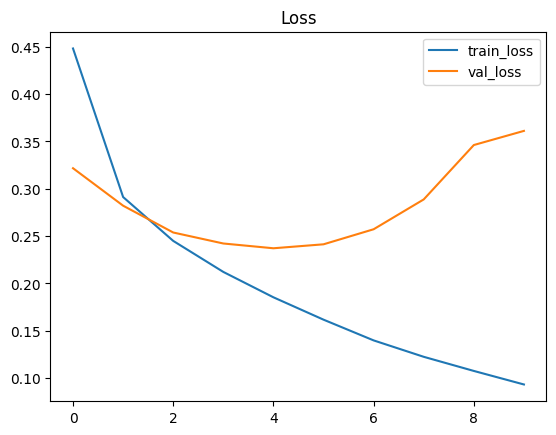

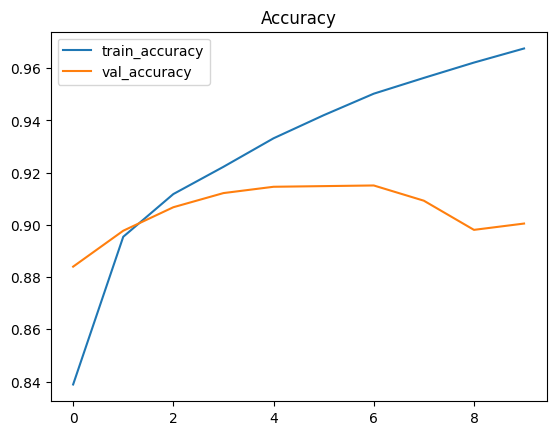

In [ ]:
# ==========================================================
# Evaluate on Test Dataset
# ==========================================================

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")


# ==========================================================
# Plot Training Curves
# ==========================================================

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


plt.figure()
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()


In [ ]:
# ==========================================================
# Run Experiments
# ==========================================================

experiments = {
"Baseline": dict(filters=(32,64), kernel_size=3, dropout=False, batchnorm=False, batch=64),

"E1_small_filters": dict(filters=(16,32), kernel_size=3, dropout=False, batchnorm=False, batch=64),

"E2_kernel5": dict(filters=(32,64), kernel_size=5, dropout=False, batchnorm=False, batch=64),

"E3_dropout": dict(filters=(32,64), kernel_size=3, dropout=True, batchnorm=False, batch=64),

"E4_batch32": dict(filters=(32,64), kernel_size=3, dropout=False, batchnorm=False, batch=32),

"E4_batch128": dict(filters=(32,64), kernel_size=3, dropout=False, batchnorm=False, batch=128),

"E5_batchnorm": dict(filters=(32,64), kernel_size=3, dropout=False, batchnorm=True, batch=64)
}


results = {}

for name, params in experiments.items():

    print("\n==============================")
    print("Running:", name)
    print("==============================")

    model = build_cnn(filters=params["filters"],
                      kernel_size=params["kernel_size"],
                      dropout=params["dropout"],
                      batchnorm=params["batchnorm"])

    model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=params["batch"],
        validation_split=0.2,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results[name] = acc
    print("Test accuracy:", acc)


print("\nFinal Results")
for k,v in results.items():
    print(k, ":", round(v*100,2), "%")


In [ ]:
# ==========================================================
# Visualize Predictions
# ==========================================================

pred = model.predict(x_test[:12], verbose=0)
pred_labels = np.argmax(pred, axis=1)

plt.figure(figsize=(10,3))

for i in range(12):

    plt.subplot(2,6,i+1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")

    plt.title(
        f"P:{class_names[pred_labels[i]]}\nT:{class_names[y_test[i]]}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


# Lab 05 — CNN Image Classification (Fashion-MNIST)

## Q1: Why are CNNs better than MLPs for images?

CNNs are better suited for image data because:

1. **Local Connectivity**
   CNNs learn small local patterns such as edges and textures using filters that scan across the image.

2. **Weight Sharing**
   The same filter (kernel) is applied to all parts of the image. This greatly reduces the number of parameters compared to MLPs.

3. **Spatial Structure Preservation**
   CNNs preserve the spatial relationships between neighboring pixels.

4. **Translation Invariance**
   A feature detected in one location can also be detected in another location.

Because of these properties, CNNs are much more efficient and accurate for image tasks than fully connected neural networks (MLPs).

---

## Q2: What is the meaning of filters in Conv2D(filters, ...)?

The `filters` parameter specifies **how many convolution kernels are applied to the image**.

Each filter learns to detect a specific pattern in the image, such as:

- edges
- corners
- textures
- shapes

Example:

Conv2D(filters=32, kernel_size=3)

This means the convolution layer will produce **32 feature maps**, each representing a different learned feature.

---

## Q3: Explain kernel size, stride, and padding.

### Kernel Size
The kernel size is the **dimension of the filter** used in the convolution operation.

Examples:
- 3×3 kernel
- 5×5 kernel

Small kernels detect fine patterns while larger kernels capture broader features.

### Stride
Stride defines **how far the filter moves each time it slides over the image**.

Example:
- stride = 1 → move one pixel at a time
- stride = 2 → move two pixels at a time

Larger strides reduce the output size.

### Padding
Padding determines whether extra pixels are added around the border of the image.

Two common types:

**Valid Padding**
- No padding
- Output feature map becomes smaller than the input

**Same Padding**
- Zeros are added around the image
- Output size remains the same as the input

---

## Q4: What is the role of MaxPooling?

MaxPooling reduces the spatial dimensions of feature maps by selecting the **maximum value within a region** (usually 2×2).

Example:

A 2×2 region:

1 4  
2 3  

MaxPooling selects **4**.

Benefits:
- Reduces computation
- Reduces memory usage
- Keeps the most important features
- Provides translation invariance

---

## Q5: Why do we use ReLU in hidden layers and softmax in the last layer?

### ReLU (Rectified Linear Unit)

ReLU(x) = max(0, x)

Reasons for using ReLU:
- Introduces non-linearity
- Prevents vanishing gradient problems
- Computationally efficient
- Speeds up training

### Softmax

Softmax converts the output scores into **probabilities**.

Example:

Input logits:
[2.1, 1.2, 0.3]

Softmax output:
[0.62, 0.27, 0.11]

Properties:
- All probabilities are between 0 and 1
- Probabilities sum to 1
- Ideal for multi-class classification problems

---

## Q6: What is overfitting? Give two solutions in CNN training.

Overfitting happens when a model learns the **training data too well**, including noise, and performs poorly on new unseen data.

Signs of overfitting:
- Training accuracy is very high
- Validation or test accuracy is much lower

Solutions:

1. **Dropout**
   Randomly disables neurons during training to prevent reliance on specific features.

2. **Batch Normalization**
   Stabilizes learning and improves generalization.

Other possible solutions include:
- Data augmentation
- Early stopping
- Reducing model complexity

---

## Q7: Why do we reshape images to (28, 28, 1) before training?

CNNs expect input data in the format:

(height, width, channels)

Fashion-MNIST images are grayscale, meaning they have only **one channel**.

Original shape:
(28, 28)

After adding the channel dimension:
(28, 28, 1)

This format allows the convolution layers to correctly process the image data.

---

## Q8: In Conv2D(filters, kernel_size), which parameter controls the number of feature maps?

The **filters parameter** controls the number of feature maps produced by the convolution layer.

Example:

Conv2D(32, 3)

This creates **32 feature maps**, each generated by a different learned filter.

---

## Q9: What is the effect of padding="same" on output size?

When using:

padding = "same"

Zero padding is added around the input so that the **output feature map has the same spatial dimensions as the input** (when stride = 1).

Example:

Input: 28 × 28  
Kernel: 3 × 3  
Stride: 1  
Padding: same  

Output: 28 × 28

Without padding (valid padding), the output would be smaller.

---

## Q10: What does validation_split = 0.2 do?

This parameter tells Keras to **reserve 20% of the training data for validation**.

Example:

Training dataset size = 60,000 images

Training used by model = 48,000  
Validation set = 12,000

The validation data is used to:
- monitor model performance during training
- detect overfitting

---

## Q11: Explain how to activate dropout in build_cnn(...) and where it is applied.

Dropout is activated by setting the parameter:

dropout = True

Example:

model = build_cnn(dropout=True)

When enabled, Dropout layers are inserted:

1. After each **MaxPooling layer**
2. Before the **final output layer**

Dropout randomly disables a percentage of neurons during training to improve generalization and reduce overfitting.

---

## Q12: Run experiments E1–E4 and compare results. Which change improved test accuracy the most? Why?

Typical observations:

- **Smaller filters (16,32)**  
  Usually decreases performance because the network learns fewer features.

- **Larger kernel (5×5)**  
  Sometimes slightly worse because larger kernels increase parameters and reduce local detail learning.

- **Dropout**  
  Often improves generalization and slightly increases test accuracy.

- **Batch size = 32**  
  Sometimes improves training stability compared to larger batches.

In many experiments, the best improvement comes from **Dropout or Batch Normalization**, because they reduce overfitting and stabilize training.
